# Step 2: Train YOLO26 on Swimming Pools

Trains YOLO26 nano, small, medium, and large via transfer learning on the manually-cleaned Roboflow export, then reports the metrics and failure cases required by the brief.

Runtime: A100 GPU, ~30 min for all four variants.

## Setup

In [1]:
!nvidia-smi

Mon Jun  1 13:41:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P0             42W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
%pip install -q "ultralytics>=8.4.52" supervision pandas matplotlib pyyaml
!yolo settings sync=False
import ultralytics; ultralytics.checks()

Ultralytics 8.4.59 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Setup complete ✅ (12 CPUs, 83.5 GB RAM, 47.2/235.7 GB disk)


## Load dataset from Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import zipfile, pathlib, yaml

ZIP_PATH = '/content/drive/MyDrive/IE/CV/roboflow/Pools.yolov8.zip'
DATA_DIR = pathlib.Path('/content/dataset_hbb')

DATA_DIR.mkdir(parents=True, exist_ok=True)
with zipfile.ZipFile(ZIP_PATH) as z:
    z.extractall(DATA_DIR)

# Rewrite data.yaml with absolute split paths so Ultralytics resolves them regardless of cwd.
DATA_YAML = DATA_DIR / 'data.yaml'
cfg = yaml.safe_load(DATA_YAML.read_text())
cfg['path'] = str(DATA_DIR)
cfg['train'] = 'train/images'
cfg['val']   = 'valid/images'
cfg['test']  = 'test/images'
DATA_YAML.write_text(yaml.safe_dump(cfg))
print(yaml.safe_dump(cfg))

names:
- swimming pool
nc: 1
path: /content/dataset_hbb
roboflow:
  license: CC BY 4.0
  project: pools-tduhd
  url: https://universe.roboflow.com/jans-workspace-l9aj6/pools-tduhd/dataset/2
  version: 2
  workspace: jans-workspace-l9aj6
test: test/images
train: train/images
val: valid/images



## Training configuration

| Parameter | Value |
|---|---|
| Pretrained weights | yolo26n / s / m / l (COCO) |
| Optimizer | AdamW (explicit, so lr0 is respected) |
| Initial LR | 0.005 |
| LR scheduler | Cosine |
| Epochs | 100 |
| Patience | 30 |
| Image size | 640 |
| Batch size | 16 |
| Mixed precision | AMP |
| Augmentations | HSV (0.015 / 0.7 / 0.4), translate 0.1, scale 0.5, flip lr/ud, rotate 180, mosaic 1.0, mixup 0.05, close_mosaic last 10 epochs |
| Hardware | NVIDIA A100 40 GB |

## Method and hyperparameter rationale

All training runs in this project share two design choices that keep the comparison fair. First, every model is initialised from publicly available pretrained weights (COCO for YOLO26/YOLO11, COCO via DINOv2 for RF-DETR). Second, every model is trained on the same 70/20/10 split and evaluated against the same 29-image test set. The hyperparameters in the table above apply identically to nano, small, medium and large; only the pretrained weights change between runs.

Two facts shape every value: the training set has only 202 images, and the targets are small rotated pools in top-down aerial imagery.

- **Learning rate (0.005, cosine).** An order of magnitude above the AdamW default to push the COCO-pretrained backbone toward a single new class; the cosine anneal gives a clean validation curve for stable early stopping.
- **Epochs 100, patience 30.** Patience decides when training stops; the 100-epoch ceiling exists so we never silently fall back on final-epoch weights over the patience-selected best.
- **Batch 16.** The largest batch that fits alongside a fully cached dataset on the A100 at imgsz 640. (RF-DETR later uses physical batch 8 with gradient accumulation 2 to match the same effective batch.)
- **Image size 640.** Matches the COCO-pretrained YOLO weights.
- **AdamW.** Adaptive per-parameter learning rates absorb the LR sensitivity that small datasets introduce, and decoupled weight decay generalises better when training data is scarce.

**Augmentation.** Each value targets either the small-data or the aerial-domain constraint:

- **Rotate up to 180°.** Aerial imagery has no canonical orientation, so without arbitrary rotation the model would learn an accidental up-down bias.
- **Mosaic 1.0.** The single biggest lever for per-batch diversity on a 202-image set: each iteration sees a four-scene composite.
- **HSV (0.015 / 0.7 / 0.4).** Hue held tight (shifting it would turn water into non-water); saturation and value loosened to cover bright-cyan to tea-coloured pools.
- **Flip lr / flip ud (both 0.5).** Free symmetry doubling for top-down imagery.
- **Mixup 0.05.** Light regulariser; the YOLO26 HBB scale inversion (nano > large) confirms overfitting is the dominant failure mode at this dataset size.
- **Translate 0.1, scale 0.5.** Ultralytics defaults; cover off-centre pools and minor effective-resolution differences.
- **Close-mosaic over last 10 epochs.** Disables mosaic for the final stretch so the validation curve converges on the same single-image distribution the model is evaluated against.

In [5]:
CFG = dict(
    data=str(DATA_YAML),
    epochs=100,
    imgsz=640,
    batch=16,
    patience=30,
    optimizer='AdamW',
    lr0=0.005,
    cos_lr=True,
    close_mosaic=10,
    seed=0,
    deterministic=True,
    cache='ram',
    plots=True,
    amp=True,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    translate=0.1, scale=0.5,
    fliplr=0.5, flipud=0.5,
    degrees=180,
    mosaic=1.0, mixup=0.05,
    exist_ok=True,
)
VARIANTS = ['yolo26n', 'yolo26s', 'yolo26m', 'yolo26l']

## Train all four variants

In [6]:
from ultralytics import YOLO
import time, gc, torch

results = {}

for v in VARIANTS:
    print(f'\n=== {v} ===')
    gc.collect(); torch.cuda.empty_cache()
    t0 = time.time()
    model = YOLO(f'{v}.pt')
    train = model.train(name=v, **CFG)
    val = model.val(data=str(DATA_YAML), split='val', verbose=False)
    results[v] = {
        'mAP50':    float(val.box.map50),
        'mAP50_95': float(val.box.map),
        'precision': float(val.box.mp),
        'recall':    float(val.box.mr),
        'params':    sum(p.numel() for p in model.model.parameters()),
        'train_time_s': time.time() - t0,
        'best_weights': str(train.save_dir / 'weights' / 'best.pt'),
    }
    del model


=== yolo26n ===
Ultralytics 8.4.59 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/dataset_hbb/data.yaml, degrees=180, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.05, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26n, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW,

## Comparison table and plots

In [7]:
import pandas as pd

df = pd.DataFrame(results).T
df['params_M'] = df['params'] / 1e6
df = df[['mAP50', 'mAP50_95', 'precision', 'recall', 'params_M', 'train_time_s']].round(4)
df.columns = ['mAP@50', 'mAP@50-95', 'Precision', 'Recall', 'Params (M)', 'Train time (s)']
df.to_csv('/content/yolo26_comparison.csv')
df

,mAP@50,mAP@50-95,Precision,Recall,Params (M),Train time (s)
yolo26n,0.912043,0.637144,0.895155,0.843284,2.375031,291.197755
yolo26s,0.891031,0.617326,0.862136,0.849268,9.465567,308.07662
yolo26m,0.902785,0.587363,0.876495,0.788556,20.350223,369.8425
yolo26l,0.90909,0.58978,0.944114,0.839506,24.746511,454.08956


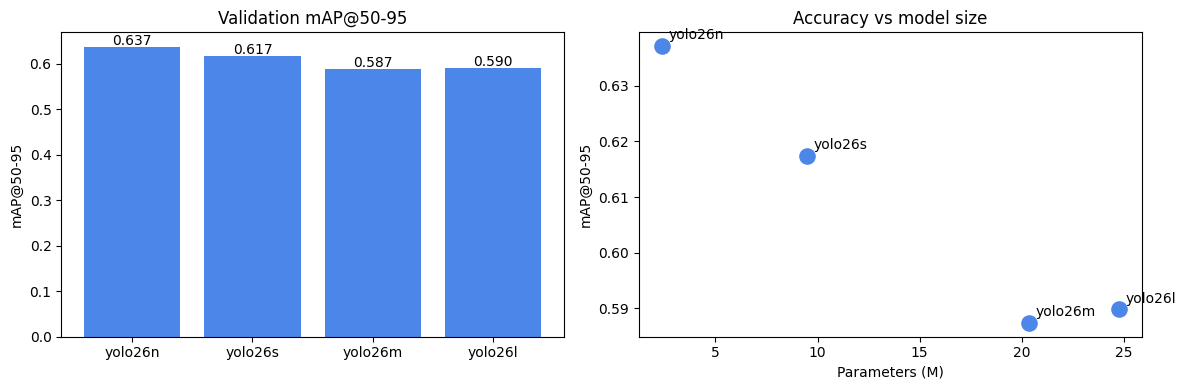

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(df.index, df['mAP@50-95'], color='#4C86E8')
axes[0].set_ylabel('mAP@50-95'); axes[0].set_title('Validation mAP@50-95')
for i, v in enumerate(df['mAP@50-95']):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center')

axes[1].scatter(df['Params (M)'], df['mAP@50-95'], s=120, c='#4C86E8')
for name, row in df.iterrows():
    axes[1].annotate(name, (row['Params (M)'], row['mAP@50-95']), xytext=(5, 5), textcoords='offset points')
axes[1].set_xlabel('Parameters (M)'); axes[1].set_ylabel('mAP@50-95'); axes[1].set_title('Accuracy vs model size')
plt.tight_layout(); plt.show()

## YOLO26 HBB scaling: accuracy, robustness, parameter count

The charts above show validation mAP@50-95 and accuracy-vs-parameters for the four YOLO26 scales. On the three dimensions the brief asks for:

- **Accuracy.** Nano leads on mAP@50-95 (0.637); small (0.617), medium (0.587), and large (0.590) are all lower. This is the classic over-parameterised pattern on a 202-image training set.
- **Robustness.** Precision is highest at the largest scale (0.895 at nano, up to 0.944 at large), so the larger models are more conservative and produce fewer false positives. Recall stays roughly flat (0.79-0.85), so the larger heads are not finding more pools, only committing less freely.
- **Parameter count.** 2.4 M to 24.7 M, a 10x growth for zero mAP@50-95 benefit (actually a 0.05 drop). Train time rises from 291 s to 454 s. The larger variants are pure cost on this dataset.

The over-parameterisation is consistent with a small training set: the larger heads find spurious patterns that hurt strict localisation. `yolo26n` is therefore the best YOLO26 HBB variant and the one carried forward to the test set.

## Best variant diagnostic plots

Best variant: yolo26n
results.png


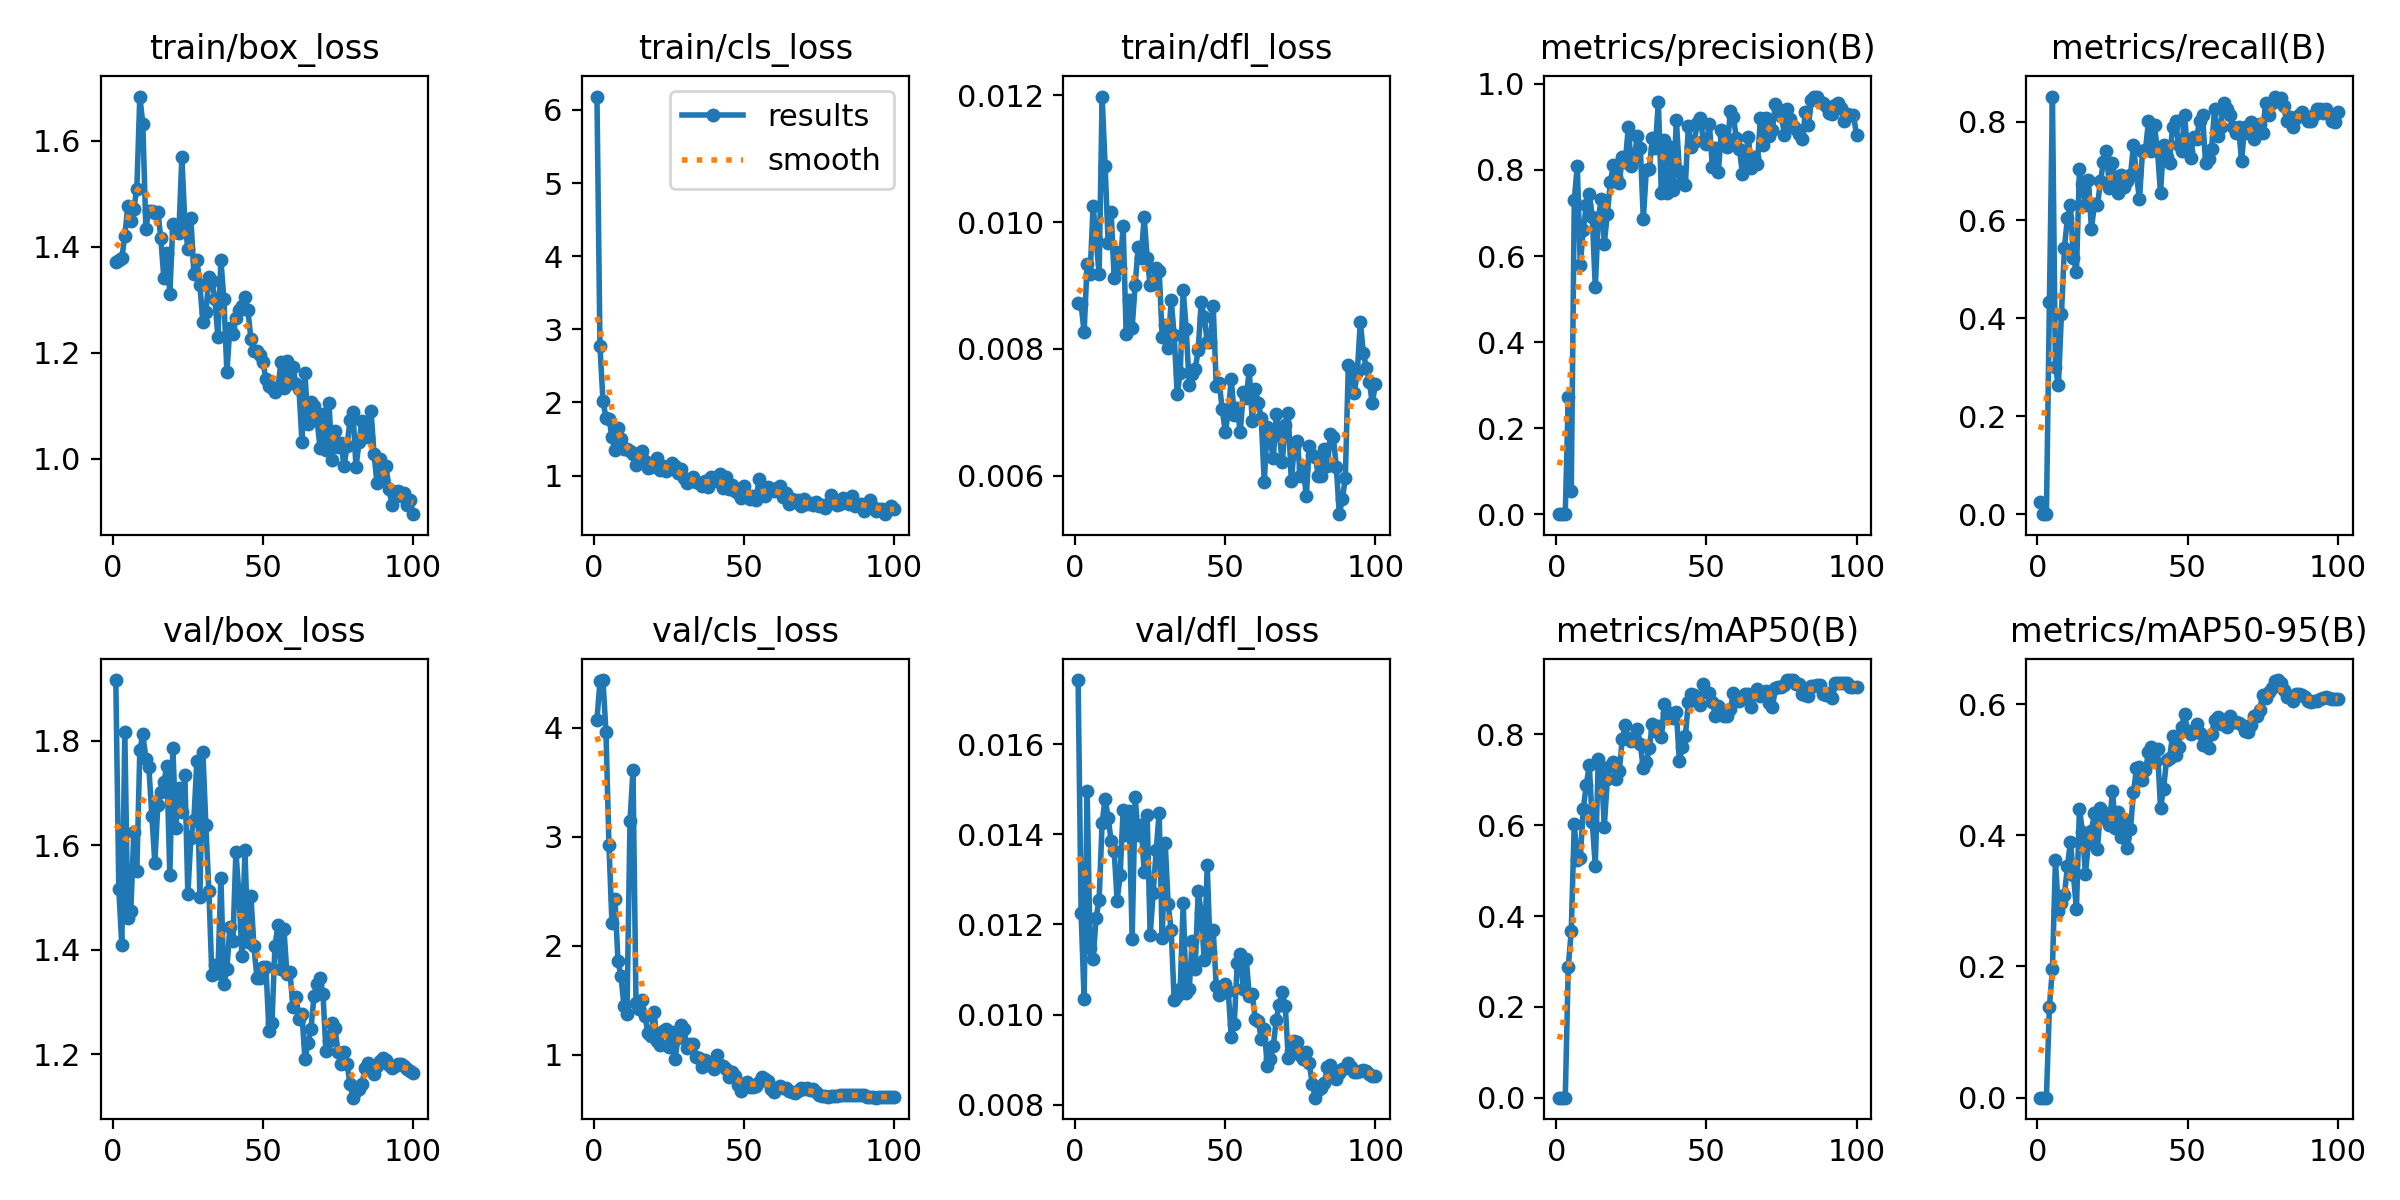

confusion_matrix.png


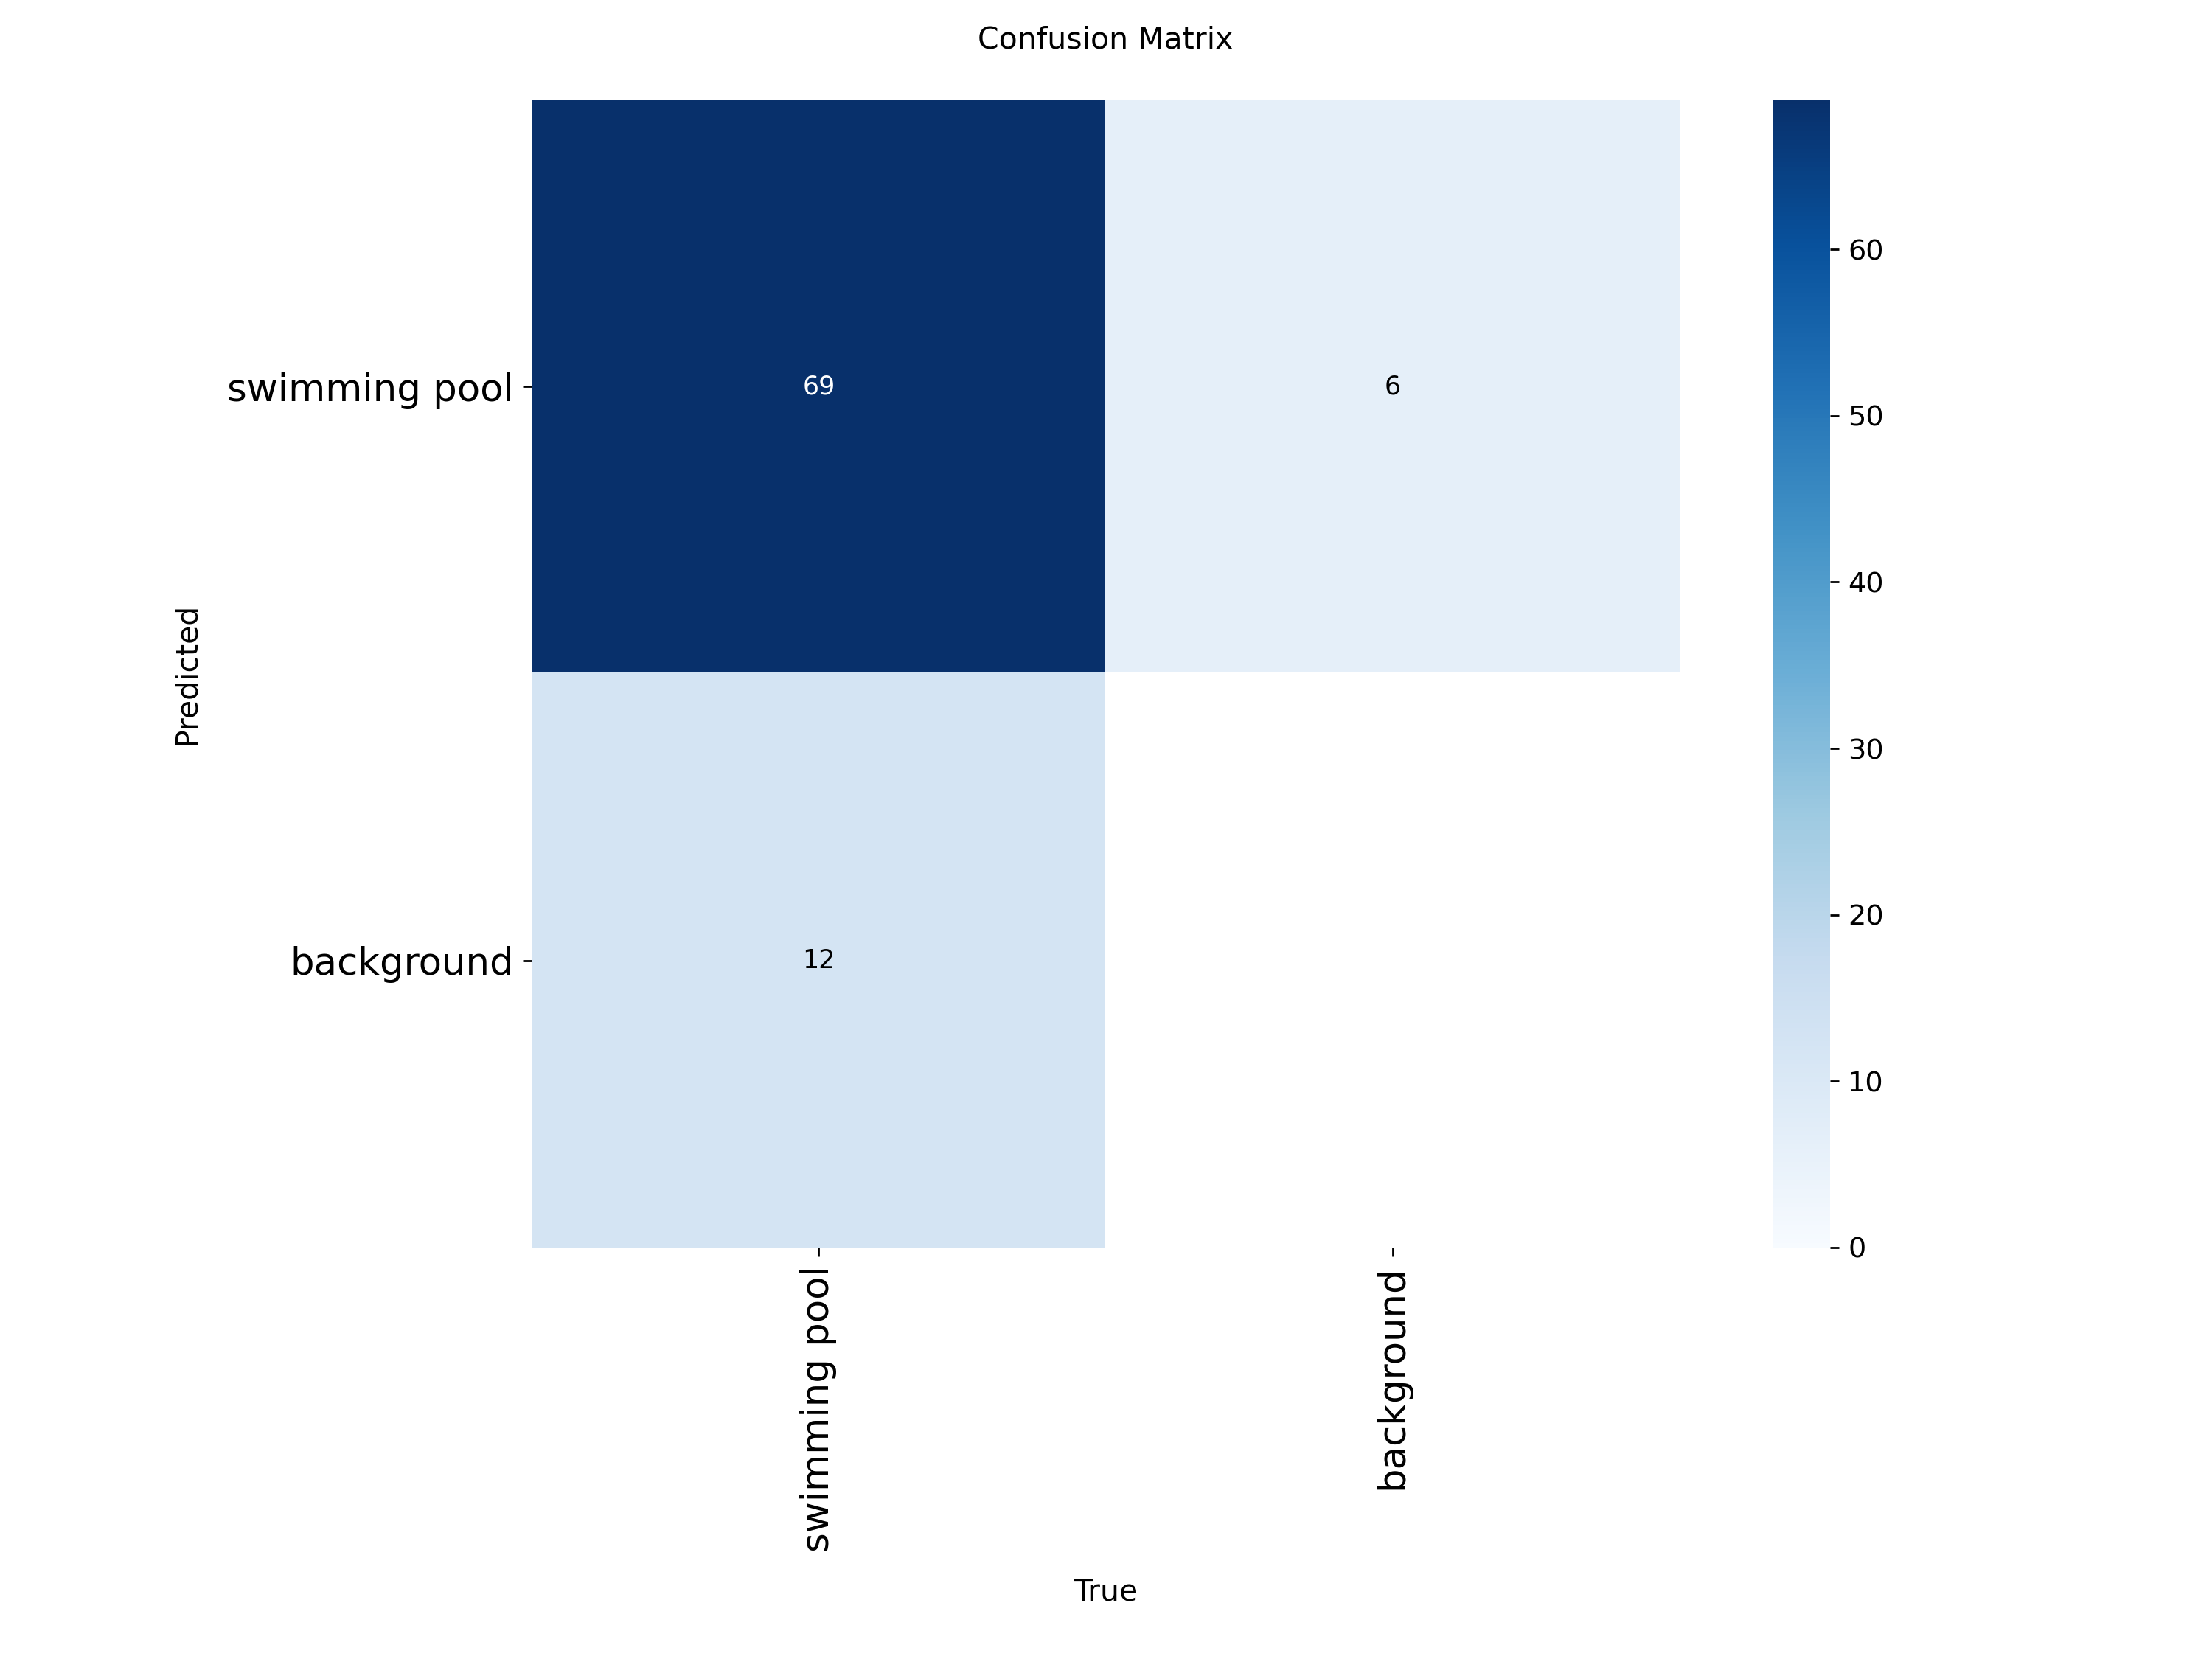

val_batch0_pred.jpg


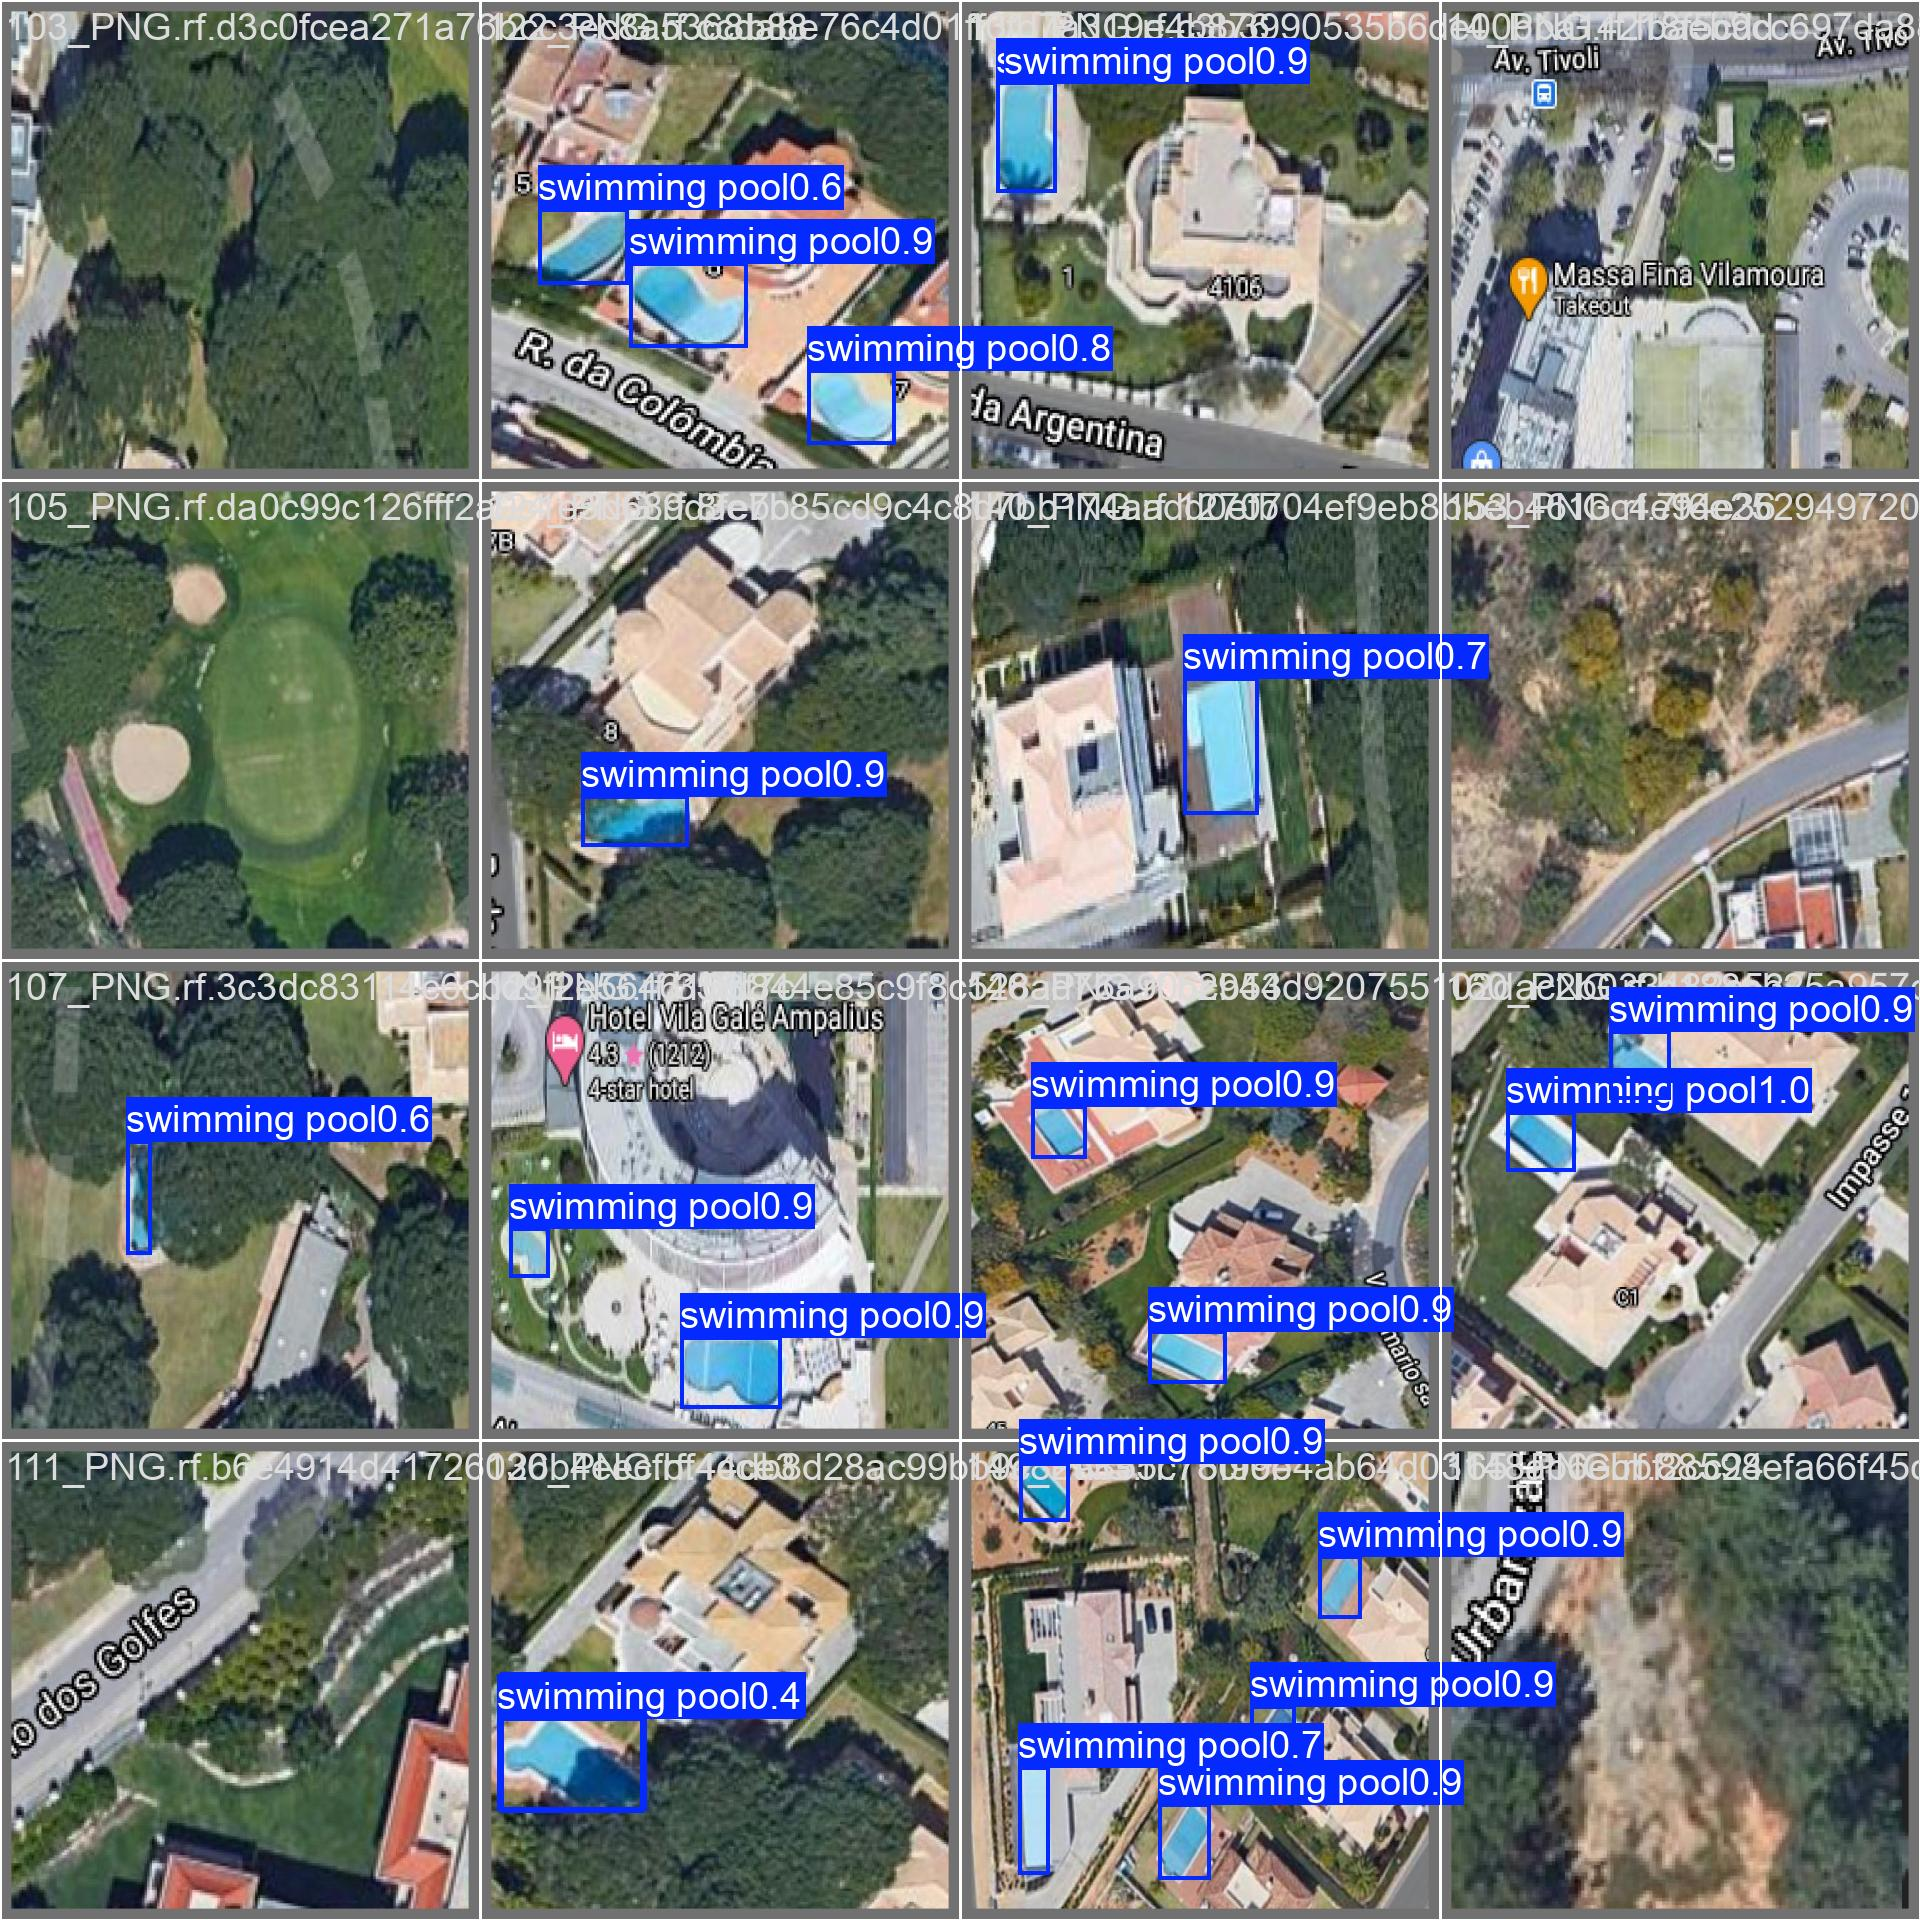

In [9]:
from IPython.display import Image as IPyImage, display
import pathlib

BEST = df['mAP@50-95'].idxmax()
print(f'Best variant: {BEST}')
RUN_DIR = pathlib.Path(f'/content/runs/detect/{BEST}')
for f in ['results.png', 'confusion_matrix.png', 'PR_curve.png', 'val_batch0_pred.jpg']:
    p = RUN_DIR / f
    if p.exists():
        print(f); display(IPyImage(filename=str(p), width=700))

## Test-set evaluation (standard + TTA)

In [10]:
best_model = YOLO(results[BEST]['best_weights'])

t_std = best_model.val(data=str(DATA_YAML), split='test', verbose=False)
print(f'TEST (no TTA):  mAP50={t_std.box.map50:.4f}  mAP50-95={t_std.box.map:.4f}  P={t_std.box.mp:.4f}  R={t_std.box.mr:.4f}')

t_tta = best_model.val(data=str(DATA_YAML), split='test', augment=True, verbose=False)
print(f'TEST (TTA on):  mAP50={t_tta.box.map50:.4f}  mAP50-95={t_tta.box.map:.4f}  P={t_tta.box.mp:.4f}  R={t_tta.box.mr:.4f}')

Ultralytics 8.4.59 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1861.4±622.0 MB/s, size: 65.4 KB)
val: Scanning /content/dataset_hbb/test/labels... 29 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 29/29 1.5Kit/s 0.0s
val: New cache created: /content/dataset_hbb/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.5it/s 0.8s
                   all         29         39      0.942      0.838      0.935      0.692
Speed: 3.1ms preprocess, 12.1ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /content/runs/detect/val-5
TEST (no TTA):  mAP50=0.9347  mAP50-95=0.6920  P=0.9423  R=0.8376
Ultralytics 8.4.59 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, r

## Test-set result and test-time augmentation

On the 29-image held-out test set the validation-best YOLO26 variant (`yolo26n`) reaches **mAP@50 = 0.935, mAP@50-95 = 0.692, P = 0.942, R = 0.838** (TP / FP / FN = 33 / 2 / 6 at the validator-tuned threshold). These numbers feed the cross-architecture comparison at the end of notebook 4.

**Test-time augmentation.** YOLO26 HBB was also evaluated with TTA enabled (above). The YOLO26 weights in this Ultralytics build silently fall back to single-scale prediction ("Model does not support augment=True"), so the TTA numbers match the standard numbers exactly. The usual +1 to +2 mAP@50-95 lift TTA gives on other YOLO variants is therefore not reflected here; the result is a no-op rather than a meaningful comparison.

## Failure analysis (FPs + FNs)

Runs the best model on the test set, matches predictions to ground truth by IoU, and dumps the highest-confidence false positives and the largest missed pools (false negatives). Inspect the gallery to write the discussion in the report.

In [11]:
import cv2, numpy as np, pathlib, matplotlib.pyplot as plt

TEST_IMG_DIR = DATA_DIR / 'test' / 'images'
TEST_LBL_DIR = DATA_DIR / 'test' / 'labels'

def load_yolo_labels(p, w, h):
    """Parse YOLO labels. Roboflow's segmentation-type project exports class +
    polygon vertices (2N coords) under the 'YOLOv8' format, so 4-token HBB and
    polygon lines both need handling. Returns axis-aligned bounding rectangles."""
    boxes = []
    if not p.exists():
        return boxes
    for line in p.read_text().splitlines():
        toks = line.split()
        if len(toks) < 5:
            continue
        coords = list(map(float, toks[1:]))
        if len(coords) == 4:
            cx, cy, bw, bh = coords
            x1 = (cx - bw/2) * w; y1 = (cy - bh/2) * h
            x2 = (cx + bw/2) * w; y2 = (cy + bh/2) * h
        else:
            xs = [coords[i] * w for i in range(0, len(coords), 2)]
            ys = [coords[i] * h for i in range(1, len(coords), 2)]
            x1, y1, x2, y2 = min(xs), min(ys), max(xs), max(ys)
        boxes.append([x1, y1, x2, y2])
    return boxes

def iou(a, b):
    xA = max(a[0], b[0]); yA = max(a[1], b[1])
    xB = min(a[2], b[2]); yB = min(a[3], b[3])
    inter = max(0, xB - xA) * max(0, yB - yA)
    union = (a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter
    return inter / union if union > 0 else 0

IOU_TH = 0.5
fps, fns = [], []

for img_p in sorted(TEST_IMG_DIR.iterdir()):
    if img_p.suffix.lower() not in {'.jpg', '.jpeg', '.png'}: continue
    img = cv2.imread(str(img_p)); h, w = img.shape[:2]
    gt = load_yolo_labels(TEST_LBL_DIR / (img_p.stem + '.txt'), w, h)

    r = best_model.predict(str(img_p), conf=0.25, verbose=False)[0]
    pred_boxes = r.boxes.xyxy.cpu().numpy()
    pred_conf  = r.boxes.conf.cpu().numpy()

    # Best-IoU greedy matching (standard COCO style), iterating preds by descending confidence.
    matched_gt, matched_pr = set(), set()
    for i in np.argsort(-pred_conf):
        best_j, best_iou = -1, IOU_TH
        for j, gb in enumerate(gt):
            if j in matched_gt: continue
            v = iou(pred_boxes[i], gb)
            if v >= best_iou:
                best_iou, best_j = v, j
        if best_j >= 0:
            matched_gt.add(best_j); matched_pr.add(int(i))

    for i in range(len(pred_boxes)):
        if i not in matched_pr:
            fps.append((img_p, pred_boxes[i].tolist(), float(pred_conf[i])))
    for j, gb in enumerate(gt):
        if j not in matched_gt:
            area = (gb[2]-gb[0])*(gb[3]-gb[1])
            fns.append((img_p, gb, area))

fps.sort(key=lambda x: -x[2])
fns.sort(key=lambda x: -x[2])
print(f'Total false positives: {len(fps)}   Total false negatives: {len(fns)}')

Total false positives: 6   Total false negatives: 5


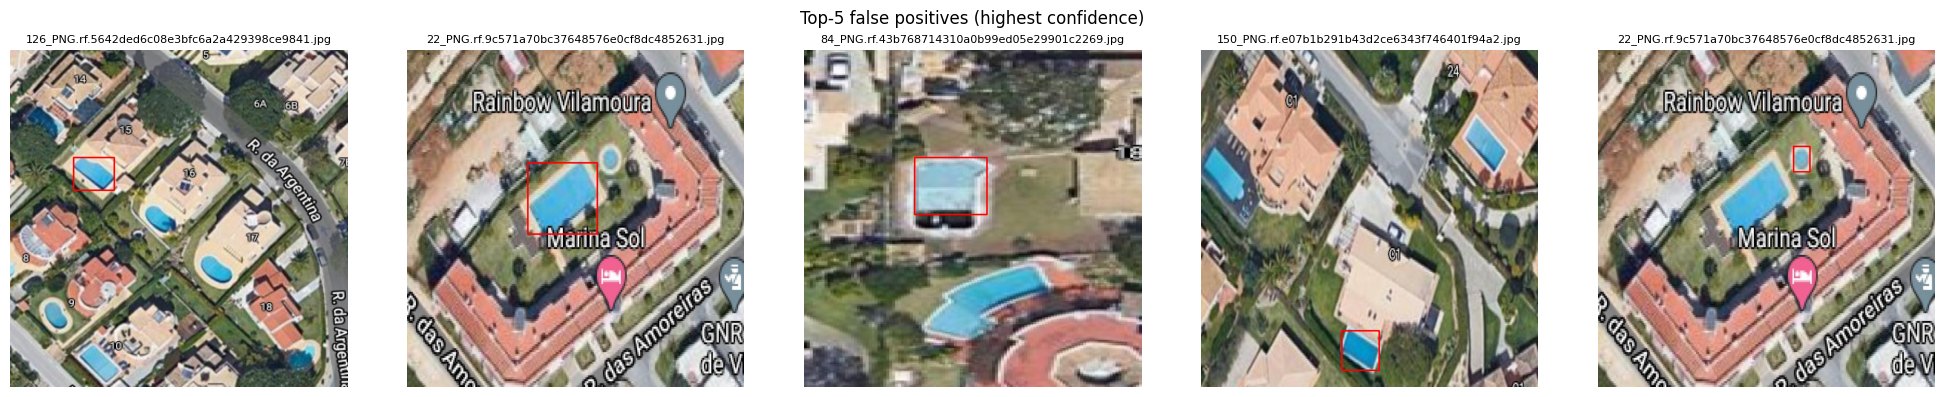

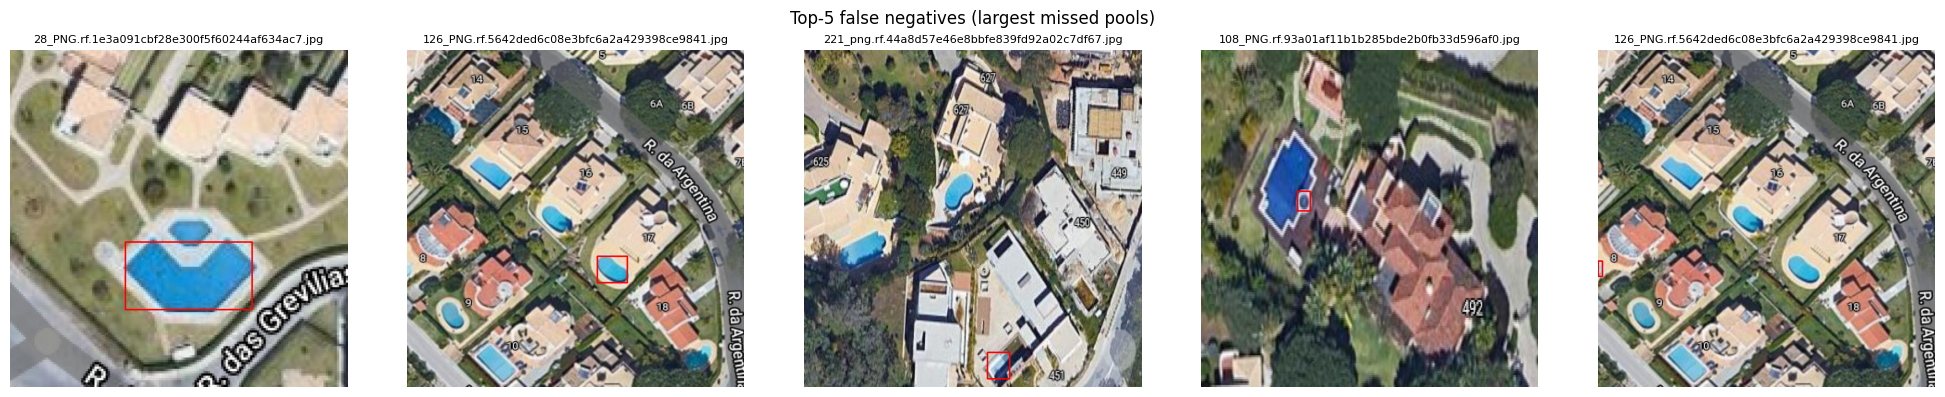

In [12]:
def show_gallery(items, title, n=5):
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    for ax, (img_p, box, _) in zip(axes, items[:n]):
        img = cv2.cvtColor(cv2.imread(str(img_p)), cv2.COLOR_BGR2RGB)
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
        ax.imshow(img); ax.set_title(img_p.name, fontsize=8); ax.axis('off')
    fig.suptitle(title); plt.tight_layout(); plt.show()

show_gallery(fps, 'Top-5 false positives (highest confidence)')
show_gallery(fns, 'Top-5 false negatives (largest missed pools)')

### Failure modes and causes (YOLO26n HBB)

The galleries above show the top false positives (by confidence) and false negatives (by area) for `yolo26n` on the test set, at conf >= 0.25 and IoU >= 0.5 (Ultralytics' default predict mode). This conf threshold is more permissive than the optimal F1 point the validator picks, so the gallery shows **6 FPs** while the validator-side test metric reports 2; the extra four are low-confidence predictions the validator filters out. Headline counts: **6 false positives, 5 false negatives** across 29 images.

The six false positives split into three causes:

| Case (image) | Cause | Evidence |
|---|---|---|
| FP1 (126_PNG, top conf) | Rotation artefact | Eight pools tilted roughly 30-45° in one tile; greedy matching breaks when many candidates overlap at the strict IoU threshold. |
| FP2 (22_PNG, large pool) | Rotation artefact | A diagonal lap pool tilted about 40°; the axis-aligned GT box is nearly twice the size of the visible water, so a tight prediction falls short of 0.5 IoU against the loose box. |
| FP3 (84_PNG) | Annotation past water | The polygon traces a dark band along one edge that the model correctly excludes; the GT box is dragged outside the visible pool boundary. |
| FP4 (150_PNG) | Rotation artefact | Three pools tilted about 35-40°; each GT box is again about twice the visible pool area. |
| FP5 & FP6 (22_PNG small pool + one similar) | Small-object IoU sensitivity | On pools this small, a misalignment of about a third of the pool's width drops IoU below 0.5, so a few-pixel offset breaks the threshold even when the prediction is visually on the pool. |

**Zero of the 6 FPs are genuine false alarms**: all are explained by the underlying ground-truth geometry. The five false negatives are all either small or unusually shaped:

- **108_PNG.** The smallest pool in the test set, below what the detector can reliably resolve at the training resolution.
- **221_png.** A small pool tilted about 25° off horizontal.
- **28_PNG.** A modestly-sized rectangular pool plus a much larger kidney-shaped pool whose curved outline does not fit either box type well.
- **126_PNG (x2).** Two small or partially shaded pools in the same densely-packed tile as FP1.

The rotation-driven FPs are the headline HBB weakness; notebook 4 shows OBB eliminates them entirely. Proposed fixes per cause are collected in the synthesis at the end of notebook 4.

## Save results to Drive

In [13]:
import shutil, pathlib

OUT = pathlib.Path('/content/drive/MyDrive/IE/CV/results/yolo26_hbb')
OUT.mkdir(parents=True, exist_ok=True)

shutil.copy('/content/yolo26_comparison.csv', OUT / 'comparison.csv')
for v in VARIANTS:
    src = pathlib.Path(results[v]['best_weights'])
    if src.exists():
        shutil.copy(src, OUT / f'{v}_best.pt')
print(f'Saved to {OUT}')

Saved to /content/drive/MyDrive/IE/CV/results/yolo26_hbb
